# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)


A figure is the whole canvas or window that holds the entire plot. An axes is the specific plotting area inside the figure where the data, axes labels, and title appear.


**2.** Name the three figure-level functions in `seaborn`.


The three figure-level functions in seaborn are relplot(), displot(), and catplot().


**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?


A histogram is used to show the distribution of numerical data by dividing the values into bins. A barplot is used to compare values across categorical groups. So, a histogram is for numerical data, while a barplot is for categorical data.

## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

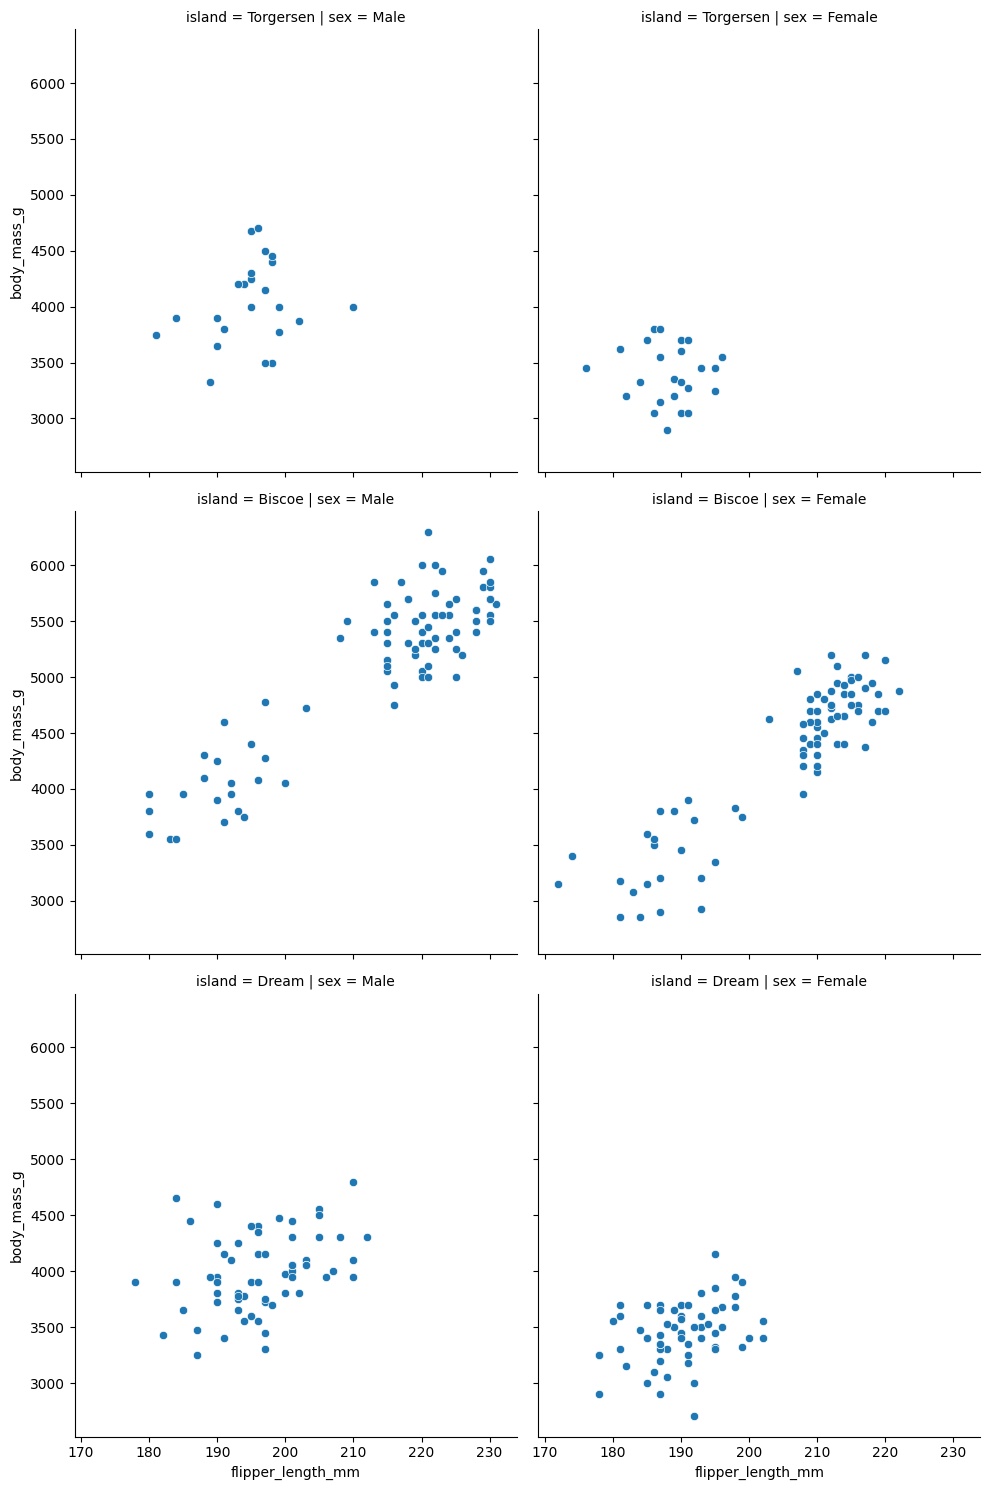

In [3]:
sns.relplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    col="sex",
    row="island",
    kind="scatter"
)

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

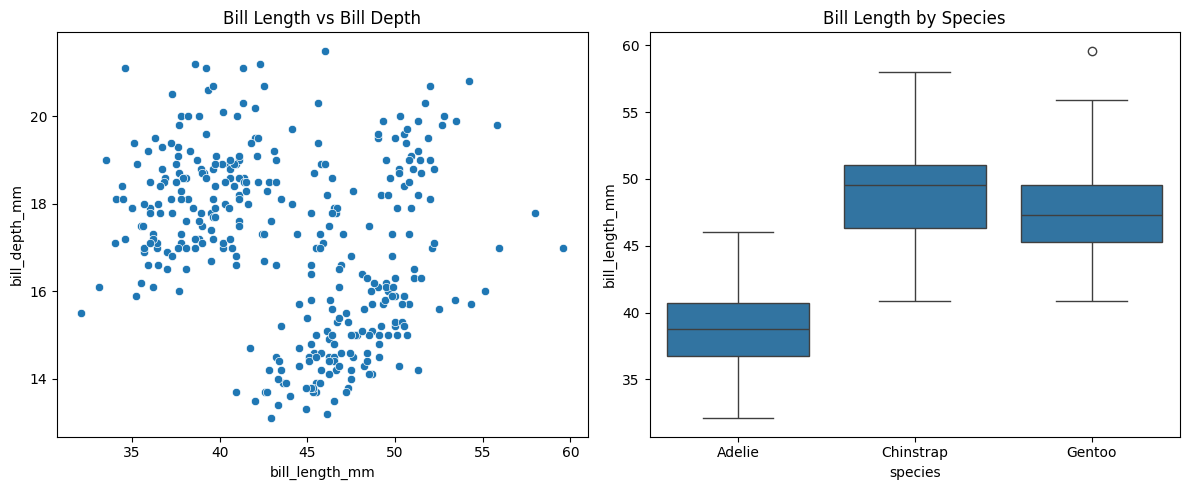

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", ax=ax1)
ax1.set_title("Bill Length vs Bill Depth")

sns.boxplot(data=df, x="species", y="bill_length_mm", ax=ax2)
ax2.set_title("Bill Length by Species")

plt.tight_layout()
plt.show()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

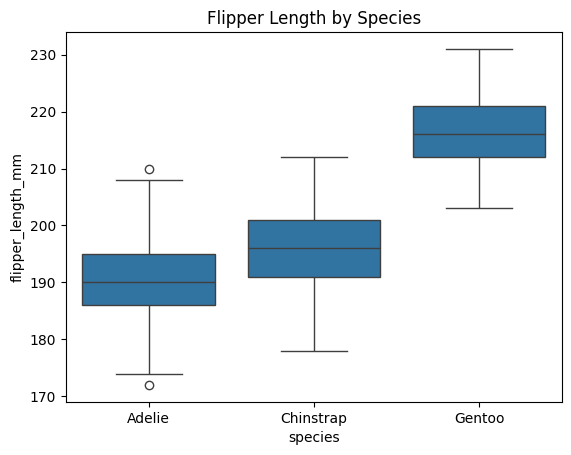

In [5]:
sns.boxplot(data=df, x="species", y="flipper_length_mm")
plt.title("Flipper Length by Species")
plt.show()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



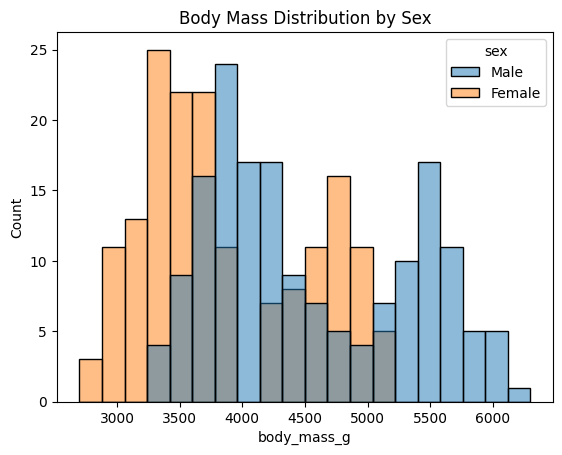

In [6]:
sns.histplot(data=df, x="body_mass_g", hue="sex", alpha=0.5, bins=20)
plt.title("Body Mass Distribution by Sex")
plt.show()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



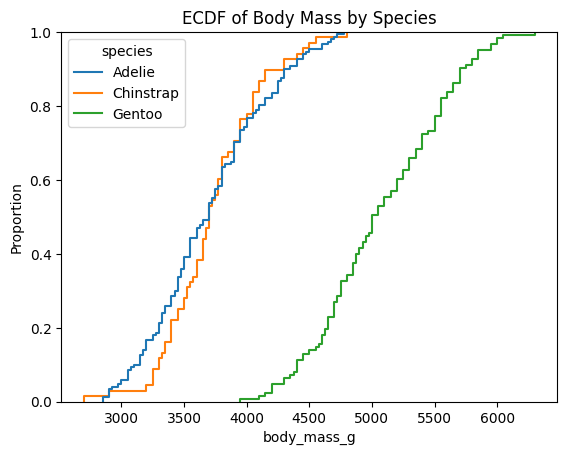

In [7]:
sns.ecdfplot(data=df, x="body_mass_g", hue="species")
plt.title("ECDF of Body Mass by Species")
plt.show()

The ECDF plot shows that Gentoo penguins are generally heavier than Adelie and Chinstrap, because the Gentoo curve is shifted further to the right. Adelie and Chinstrap have lower body mass overall and their curves overlap more, which means their weights are more similar to each other.


**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



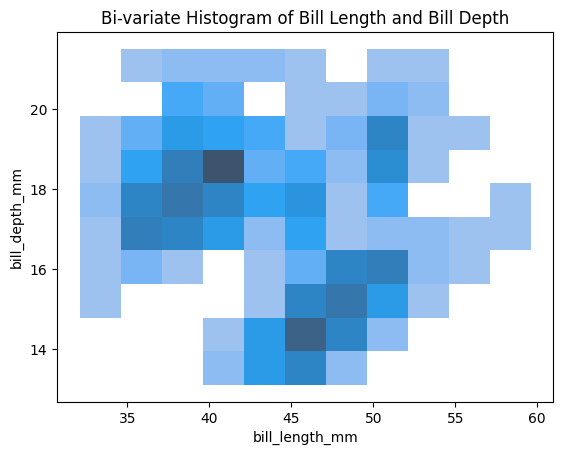

In [8]:
sns.histplot(data=df, x="bill_length_mm", y="bill_depth_mm")
plt.title("Bi-variate Histogram of Bill Length and Bill Depth")
plt.show()

The intensity mapping, or the color blocks, represents the number of observations in each area of the plot. Darker or stronger color means that more penguins have bill length and bill depth values in that range, so it shows where the data is more concentrated.

## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

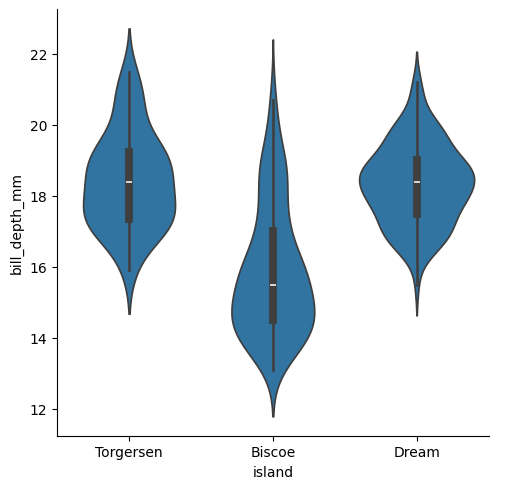

In [9]:
sns.catplot(data=df, x="island", y="bill_depth_mm", kind="violin")
plt.show()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

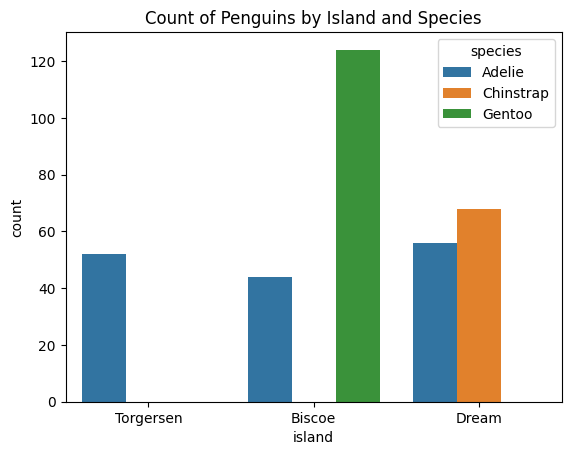

In [10]:
sns.countplot(data=df, x="island", hue="species")
plt.title("Count of Penguins by Island and Species")
plt.show()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

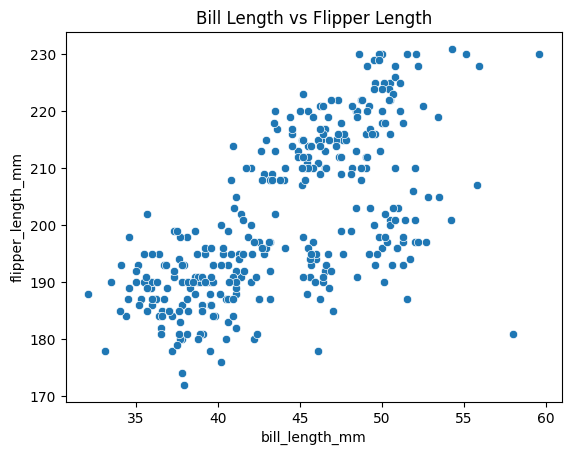

In [11]:
sns.scatterplot(data=df, x="bill_length_mm", y="flipper_length_mm")
plt.title("Bill Length vs Flipper Length")
plt.show()

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

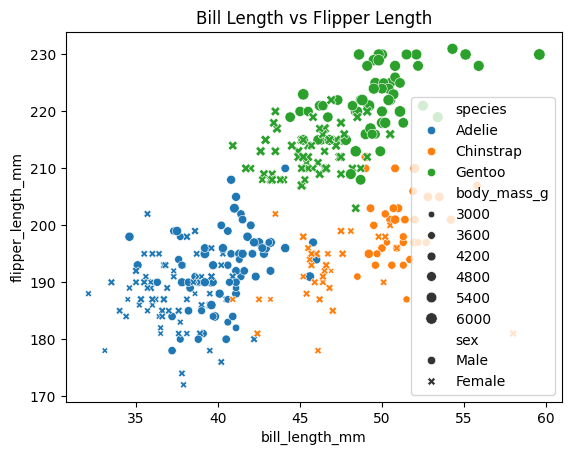

In [12]:
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="sex",
    size="body_mass_g"
)
plt.title("Bill Length vs Flipper Length")
plt.show()